# 记忆的进化：GRU与长期依赖问题

通过本次任务，你将学会如何使用 GRU 提高情感分析模型的能力。

## 任务背景
深夜的办公室，奶茶店后台系统的用户评价仍如潮水般涌入，每一条都承载着市场的真实声音。然而，最新一轮模型评估的结果却令人皱眉——分类效果依旧不尽如人意。市场不会等待，竞品迭代日新月异，若不能从评价中快速识别关键反馈，产品优化便如盲人摸象，难以切中需求。时间，正成为我们最昂贵的成本。

想象一下，如果我们的记忆不分轻重，把所有信息都牢牢记住，会是什么样子？早上通勤时看到的广告牌、昨天会议的每一句对话、上周读过的书中每一个字……这样的记忆不仅负担沉重，还会让我们难以抓住真正重要的信息。

传统循环神经网络（RNN）就面临着类似的困境。它虽然拥有了“记忆”能力，能够处理序列数据，但却是一种“平等式记忆”——所有信息都以相同程度被保留和传递。眼下它就陷入了这种困境：它太想记住所有信息了。就像一个过分认真的记录者，不放过每一个词语——无论是转折的“但”、含糊的“好像”，还是琐碎的“那天”，它都一视同仁地存入记忆。结果，真正决定体验的关键反馈，如“珍珠偏硬”、“甜度过高”、“服务很贴心”，反而被淹没在无关细节的噪声中。

若能赋予模型人类般的"选择性遗忘"能力：让它自主决定"何时专注新信息，何时过滤干扰，何时融合历史记忆"，便能从纷杂评价中精准提取决定产品成败的黄金线索。

那么，我们该如何着手，为模型赋予这种“选择性记忆”的智慧呢？

## 最少必要知识
- 梯度消失和梯度爆炸
- 门控 RNN
- 多层 RNN

## 任务鸟瞰

### 任务分析

本次的任务是使用 GRU 代替基础 RNN 来优化情感分析模型，提高模型的性能。

![任务鸟瞰](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211094410.png)

由于 RNN 反向传播时，梯度会流经 `tanh`和 `MatMul`（矩阵乘积）会导致梯度消失和梯度爆炸，对于长序列文本的处理能力有限。

![RNN梯度反向传播](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211092320.png)

为了解决在 RNN 的学习中梯度消失的问题，需要从根本上改变 RNN 层的结构，需要引入门机制和记忆单元。其，最具代表性的就是 LSTM 和 GRU，它们都通过引入门控机制来控制信息流的流向，并且改变了 RNNCell 中的隐藏状态的计算方式，使得模型在处理长序列时更稳定。

LSTM 计算图如下：

![LSTM计算图](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211103554.png)

GRU 层计算图如下：

![GRU计算图](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211104351.png)


在 LSTM 和 GRU 的反向传播仅流过“+”和“×”节点。

LSTM 反向传播示意图：

![LSTM反向传播](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211104331.png)

GRU 反向传播示意图：

![GRU梯度反向传播](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211104407.png)


“+”节点将上游传来的梯度原样流出，梯度没有变化（退化）。而“×”节点的计算并不是矩阵乘积，而是对应元素的乘积（阿达玛积）。这就是它们不会发生梯度消失（或梯度爆炸）的原因。

这里我们不再深入探讨 LSTM 和 GRU 的具体实现细节，而主要从层视图和计算单元视图的角度，简要对比它们与传统 RNN 的异同。

### 模型结构

在神经网络模型中，我们通常采用模块化设计，将网络构建为一系列层的堆叠。基于这种层状架构，我们可以像拼接乐高积木一样灵活组合不同模块，也能够方便地使用功能相似的层进行替换。得益于神经网络模型的模块化设计理念，我们可以轻松地使用 LSTM 和 GRU 层替换掉 RNN 层。

RNN、LSTM和GRU输入输出的对比：

![RNN模块化](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211103543.png)


在一般的情况下，我们通常首选门控循环单元（GRU）。相较于长短期记忆网络（LSTM），GRU实现了结构的简化，使其在保持与 LSTM 相近性能的同时，具备了显著的高效性，因此在计算资源有限、需要更快训练速度，或数据量不是很大的场景中，GRU 通常是更优的选择。

接下来，我们将采用 GRU 来优化情感分析模型。模型结构如下：

![模型结构](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211104446.png)

下面我们进入实战部分，依然沿用 NLP 任务的通用开发流程组织本章内容：定义分词器、数据准备、模型定义、模型训练与模型评估。其中的重复代码不再进行赘述。

我们先配置好环境，避免因为环境不同而导致程序不能复现。

## 环境配置

### 安装依赖

In [ ]:
!pip install --upgrade dsxllm

### 环境版本

In [2]:
from dsxllm.util import show_version

show_version()

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


本书愿景：
+------+--------------------------------------------------------+
| Info |                  《动手学大语言模型》                  |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.10.0    |         2.6.1          |
+-------------+--------------+------------------------+


## 自定义分词器

此部分代码和前面章节一致。

In [3]:
class SimpleTokenizer:
    def __init__(self, pad_at_beginning=False):
        """
        初始化简单分词器
        """
        # 特殊token
        self.pad_token = '[PAD]'
        self.unk_token = '[UNK]'
        self.pad_at_beginning = pad_at_beginning

        # 特殊token ID
        self.pad_token_id = 0
        self.unk_token_id = 1

        # 构建词汇表
        self.vocab = {
            self.pad_token: self.pad_token_id,
            self.unk_token: self.unk_token_id,
        }

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def build_vocab(self, texts):
        """
        根据文本构建词汇表
        """
        for text in texts:
            words = list(text)  # 将每个汉字作为独立token

            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = self.vocab_size
                    self.ids_to_tokens[self.vocab_size] = word
                    self.vocab_size += 1

    def build_vocab_from_file(self, file_path):
        """
        从文件中构建词汇表
        """
        texts = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                texts.append(line.strip())

        self.build_vocab(texts)

    def encode(self, text):
        """
        将文本编码为token ids
        """
        tokens = list(text)

        # 转换为IDs
        token_ids = []
        for token in tokens:
            if token in self.vocab:
                token_ids.append(self.vocab[token])
            else:
                token_ids.append(self.unk_token_id)

        return token_ids

    def decode(self, token_ids):
        """
        将token ids解码为文本
        """
        tokens = []
        for token_id in token_ids:
            if token_id in self.ids_to_tokens:
                token = self.ids_to_tokens[token_id]
                # 过滤特殊token（可根据需要调整）
                if token not in [self.pad_token]:
                    tokens.append(token)

        return ''.join(tokens)

    def pad_sequences(self, sequences, max_length, pad_at_beginning=False):
        """
        对序列进行填充或截断
        
        Args:
            sequences: 序列列表
            max_length: 最大长度
            pad_at_beginning: 是否在序列开头填充，默认为False（在末尾填充）
        """
        padded_sequences = []

        for seq in sequences:
            if len(seq) > max_length:
                # 截断
                if pad_at_beginning:
                    # 从开头截断
                    padded_seq = seq[len(seq) - max_length:]
                else:
                    # 从末尾截断
                    padded_seq = seq[:max_length]
            else:
                # 填充
                pad_length = max_length - len(seq)
                padding = [self.pad_token_id] * pad_length
                if pad_at_beginning:
                    # 在开头填充
                    padded_seq = padding + seq
                else:
                    # 在末尾填充
                    padded_seq = seq + padding

            padded_sequences.append(padded_seq)

        return padded_sequences

    def __call__(self, texts, max_length=128):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        # 填充或截断到统一长度
        padded_token_ids = self.pad_sequences(all_token_ids, max_length, self.pad_at_beginning)

        if is_single_text:
            padded_token_ids = padded_token_ids[0]

        return padded_token_ids

## 准备数据


### 数据集下载

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('dataset'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">数据集下载</h4>
                <p class="card-text">
                    如果你想要亲自动手复现运行结果，可以点击此链接下载相关数据集。
                </p>
            </div>
        </div>
    </div>
</a>
```

### 数据转换器

将文本转换为 token ids 的转换器。

In [4]:
import torch
import torch.nn.functional as F


class TextTransform:
    def __init__(self, tokenizer, max_length=20, vocab_size=None):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.vocab_size = vocab_size or tokenizer.vocab_size

    def __call__(self, text):
        # 使用 tokenizer 对文本进行编码，并自动完成截断与填充
        input_ids = self.tokenizer(
            text,
            max_length=self.max_length,  # 最大序列长度
        )

        # 如果 input_ids 不是 tensor，则转换为 tensor
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.long)

        return input_ids

### 自定义数据集

In [5]:
import torch
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = self.transform(text)

        return {
            "input_ids": input_ids,
            "labels": torch.tensor(label, dtype=torch.long)
        }

    @classmethod
    def from_file(cls, file_path, transform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []
        labels = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    # 使用制表符分割
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        label = int(parts[0])  # 第一列是标签
                        text = '\t'.join(parts[1:])  # 剩余部分是文本（处理文本中可能包含制表符的情况）
                        texts.append(text)
                        labels.append(label)

        # 创建数据集实例
        return cls(texts, labels, transform)

### 自定义数据模组

In [6]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size, transform, train_data_file, val_data_file="", test_data_file=""):
        super().__init__()

        # 训练、验证和测试数据文件路径
        self.train_data_file = train_data_file  # 训练数据文件路径
        self.val_data_file = val_data_file  # 验证数据文件路径（可选）
        self.test_data_file = test_data_file  # 测试数据文件路径（可选）

        # 数据集实例，初始为None，在setup方法中初始化
        self.test_dataset = None  # 测试数据集
        self.val_dataset = None  # 验证数据集
        self.train_dataset = None  # 训练数据集

        # 批次大小和数据转换器
        self.batch_size = batch_size  # 每个批次的样本数量
        self.transform = transform  # 数据转换器，用于预处理数据

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        # 此方法通常用于下载数据或进行一次性操作
        pass

    def setup(self, stage=None):
        # 根据阶段加载数据集
        # 加载训练数据集
        self.train_dataset = TextClassificationDataset.from_file(self.train_data_file, transform=self.transform)

        # 如果未提供验证数据文件，则使用训练数据集作为验证集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            # 否则加载指定的验证数据集
            self.val_dataset = TextClassificationDataset.from_file(self.val_data_file, transform=self.transform)

        # 如果未提供测试数据文件，则使用验证数据集作为测试集
        if self.test_data_file == "":
            self.test_dataset = self.val_dataset
        else:
            # 否则加载指定的测试数据集
            self.test_dataset = TextClassificationDataset.from_file(self.test_data_file, transform=self.transform)

    def train_dataloader(self):
        # 返回训练数据的DataLoader，启用shuffle以打乱数据顺序
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        # 返回验证数据的DataLoader，不打乱数据顺序
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        # 返回测试数据的DataLoader，不打乱数据顺序
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

## 改进情感分析模型

本项目使用 GRU 替换之前的 RNN 模型。从下图中可以看到，RNN 层和 GRU 层的输入和输出都是一样的，因此可以方便地进行替换，几乎不用修改代码。

![RNN模块化](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211103543.png)

主要改动有以下几点：
1. 在 `__init__()` 中使用 `nn.GRU` 替换自定义的 `RNN` 层；
2. 在 `forward()` 中使用 `gru` 层处理序列数据；

`gru` 前向计算时会返回两个值，第一个是每个时间步的输出结果 `gru_output`，第二个是最后一个时间步的隐藏状态 `gru_hidden`。

`gru_hidden` 是最终的隐藏状态，通常用于分类任务或作为后续层的输入。形状：(num_layers * num_directions, batch_size, hidden_size)。
- num_layers：GRU 的层数。
- num_directions：方向数（单向为 1，双向为 2）。
- batch_size：批次大小。
- hidden_size：GRU 隐藏层的维度。

本项目使用的是默认的配置，即 `num_layers=1` 和 `batch_first=False`，即单层单向的 GRU 层。双向化和多层化是提高 GRU 层效果的常用技巧。

多个 GRU 层堆叠示意图：

![双层GRU架构](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211104433.png)

使用多个 GRU 层处理文本的过程如下：

![双层GRU示例](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211105430.png)

所以最后一层的最后一个隐藏状态 `gru_hidden[-1]` 即为文本序列最终的隐藏状态，用它作为输出层的输入即可。具体过程如下图所示：

![多层GRU的文本分分类](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260211133733.png)


### 基于 GRU 的情感分析模型的代码实现

In [7]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, vocab_size=10, hidden_size=128, num_classes=2, learning_rate=0.01, dropout_p=0.1):
        super(TextClassifier, self).__init__()
        self.learning_rate = learning_rate

        # 定义网络层
        # 嵌入层：将词索引映射到高维向量
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=hidden_size)
        # 🌟改进点🌟 GRU层：用于处理序列数据
        self.gru = nn.GRU(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)
        # Dropout层：防止过拟合
        self.dropout = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(in_features=hidden_size, out_features=num_classes)

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.randint(0, vocab_size, (32, 30), dtype=torch.long)

        # 标签id到标签的映射，用于预测解码
        self.label_map = None

    def forward(self, input_ids):
        """前向传播"""
        token_embeds = self.dropout(self.embedding_layer(input_ids))  # 嵌入并应用dropout
        
        """
        🌟改进点🌟 通过GRU处理, 得到输出和隐藏状态
        - gru_output 是 GRU 层在每个时间步的输出结果。形状为(batch_size, sequence_length, hidden_size)
            - batch_size：批次大小。
            - sequence_length：输入序列的长度。
            - hidden_size：GRU 隐藏层的维度。
        
        - gru_hidden 是 GRU 层最后一个时间步的隐藏状态。形状：(num_layers * num_directions, batch_size, hidden_size)。
            - num_layers：GRU 的层数。
            - num_directions：方向数（单向为 1，双向为 2）。
            - batch_size：批次大小。
            - hidden_size：GRU 隐藏层的维度。
        
        gru_hidden 是最终的隐藏状态，通常用于分类任务或作为后续层的输入。
        """
        gru_output, gru_hidden = self.gru(token_embeds)

        # 取出最后一层的隐藏状态（对于单层GRU，索引为-1或0都可以）
        last_hidden = gru_hidden[-1]  # 形状: (batch_size, hidden_size)

        # 将最后一个时间步的特征输入到输出层
        out = self.output_layer(last_hidden)  # 形状: (batch_size, num_classes)

        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)
        loss = F.cross_entropy(outputs, labels)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_ids = batch["input_ids"]
        target_ids = batch["labels"]

        # 前向传播
        outputs = self(input_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': target_ids})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, label_map=None):
        """根据数据集设置标签映射"""
        self.label_map = label_map

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        # 【新增】判断输入类型并处理
        if isinstance(input_ids, list):
            input_ids = torch.stack(input_ids)  # 转换为张量

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.label_map[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.label_map[label_id] for label_id in label_ids]

### 基于 GRU 的情感分析模型的详细信息

In [8]:
from lightning.pytorch.utilities.model_summary import ModelSummary

# 初始化分词器，并从训练数据文件中构建词汇表
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file("./dataset/comments_train.txt")

# 创建基于 GRU 的文本分类模型实例
model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# 使用 ModelSummary 工具生成模型的详细摘要信息
summary = ModelSummary(model, max_depth=-1)

# 打印模型摘要信息，包括各层的参数量、输入输出形状等
print(summary)

  | Name            | Type      | Params | Mode  | FLOPs  | In sizes      | Out sizes                    
---------------------------------------------------------------------------------------------------------------
0 | embedding_layer | Embedding | 220 K  | train | 0      | [32, 30]      | [32, 30, 128]                
1 | gru             | GRU       | 99.1 K | train | 188 M  | [32, 30, 128] | [[32, 30, 128], [1, 32, 128]]
2 | dropout         | Dropout   | 0      | train | 0      | [32, 30, 128] | [32, 30, 128]                
3 | output_layer    | Linear    | 258    | train | 16.4 K | [32, 128]     | [32, 2]                      
---------------------------------------------------------------------------------------------------------------
320 K     Trainable params
0         Non-trainable params
320 K     Total params
1.281     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
188 M     Total Flops


从模型摘要信息中，可以看到 `gru` 层的输出形状为 `[[32, 30, 128], [1, 32, 128]]`，两个部分分别对应着 `gru_output` 和 `gru_hidden`。
- `gru_output`：gru 层输出的形状为 `[batch_size, seq_len, hidden_size]`，即对 32 个样本的 30 个 Token 都生成一个 128 维的隐藏状态向量。
- `gru_hidden`：gru 层隐藏状态的形状为 `[num_layers * num_directions, batch_size, hidden_size]`，即对 32 个样本分别生成一个 128 维的表示整段文本的语义的隐藏状态向量。


## 模型的训练与评估

### 初始化模型和训练器

In [9]:
# 超参配置
max_length = 30
batch_size = 32

# 1️⃣ 创建分词器，从训练数据文件中构建词汇表
tokenizer = SimpleTokenizer(pad_at_beginning=True)
tokenizer.build_vocab_from_file("./dataset/comments_train.txt")

# 2️⃣ 创建数据转换器
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 创建 DataModule 实例
datamodule = TextDataModule(batch_size=batch_size, transform=transform, train_data_file="./dataset/comments_train.txt")

# 4️⃣ 创建 TextClassifier 实例
model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=2, learning_rate=0.001)

# 5️⃣ 创建 Trainer 实例
# - max_epochs=12: 最大训练轮数为12
# - log_every_n_steps=3: 每3个步骤记录一次日志
# - check_val_every_n_epoch=1: 每1个epoch进行一次验证
# - enable_progress_bar=False: 不显示进度条
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0,
                    enable_progress_bar=False)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 训练前评估

训练前评估为模型性能建立初始基准。

In [10]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1323.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.48497068881988525    │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1323.0,
  'val_overall_acc': 0.48497068881988525}]

模型训练前模型的准确率为 `48.49%`，模型不能区分顾客评价中的情感倾向。

### 训练模型

调用 `trainer.fit()` 训练 12 个轮次。

In [11]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name            ┃ Type      ┃ Params ┃ Mode  ┃  FLOPs ┃      In sizes ┃                     Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ embedding_layer │ Embedding │  220 K │ train │      0 │      [32, 30] │                 [32, 30, 128] │
│ 1 │ gru             │ GRU       │ 99.1 K │ train │  188 M │ [32, 30, 128] │ [[32, 30, 128], [1, 32, 128]] │
│ 2 │ dropout         │ Dropout   │      0 │ train │      0 │ [32, 30, 128] │                 [32, 30, 128] │
│ 3 │ output_layer    │ Linear    │    258 │ train │ 16.4 K │     [32, 128] │                       [32, 2] │
└───┴─────────────────┴───────────┴────────┴───────┴────────┴───────────────┴───────────────────────────────┘

Trainable params: 320 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 320 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 188 M

`Trainer.fit` stopped: `max_epochs=12` reached.


#### 训练过程可视化

绘制训练过程中损失值的变化曲线。

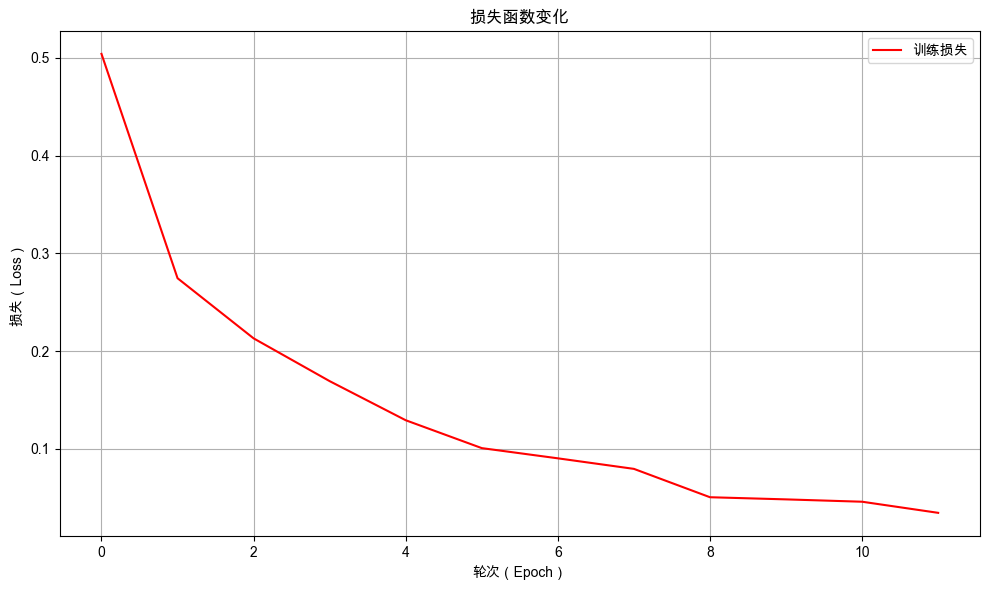

In [12]:
from dsxllm.util import plot_loss_curves

plot_loss_curves(model.train_epoch_losses)


#### 查看模型评估记录

查看训练过程中的评估结果，观察模型在验证集上的表现。

In [13]:
from dsxllm.util import to_dataframe

to_dataframe(model.eval_accuracies)


,epoch,总样本数,正确样本数,准确率
0,0,2728,2431,0.8911
1,1,2728,2542,0.9318
2,2,2728,2590,0.9494
3,3,2728,2644,0.9692
4,4,2728,2662,0.9758
5,5,2728,2684,0.9839
6,6,2728,2686,0.9846
7,7,2728,2695,0.9879
8,8,2728,2706,0.9919
9,9,2728,2710,0.9934


### 训练后评估


In [14]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2721.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.9974340200424194     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 2721.0,
  'val_overall_acc': 0.9974340200424194}]

模型经过训练后，预测准确率从 `48.49%` 提升至 `99.74%`。相比之前有显著提升，说明使用 GRU 模型在处理长文本数据时表现非常优秀。

## 使用模型进行预测

针对一组包含不同长度（短、中、长）且情感倾向明确的顾客评论进行推理预测，直观观察模型的预测效果。

In [15]:
model.setup_label_map(label_map={0: "负面", 1: "正面"})

from dsxllm.util import print_classification_predictions

# 1. 准备需要预测的文本（长短不一）
new_texts = [
    # 短文本
    "非常好",
    "质量差",
    "推荐购买",
    "不建议买",

    # 中等长度文本
    "这个产品还不错",
    "物流速度太慢了",
    "性价比很高值得推荐",

    # 长文本
    "包装很精美，产品和描述一致，非常满意这次购物体验",
    "卖家服务态度不好，发货速度慢，产品质量也不如预期",
    "虽然价格有点贵，但是品质确实不错，使用效果很满意"
]

true_labels = [1, 0, 1, 0, 1, 0, 1, 1, 0, 1]

# 2. 使用与训练时统一的 transform 方法对文本进行处理
input_ids = []
for text in new_texts:
    # 使用训练时相同的 transform 方法
    transformed = transform(text)
    input_ids.append(transformed)

# 3. 使用模型进行预测
predictions, decoded_predictions, probabilities = model.predict(input_ids)

# 4. 输出预测结果
print_classification_predictions(new_texts, true_labels, predictions, probabilities, model.label_map)

🎯 分类预测结果 (准确率: 10/10 = 100.00%)：
+--------------------------------------------------+----------+----------+----------+------+
|                       输入                       | 真实标签 | 预测标签 | 最高概率 | 标记 |
+--------------------------------------------------+----------+----------+----------+------+
|                      非常好                      |   正面   |   正面   |  0.9992  |  ☑   |
|                      质量差                      |   负面   |   负面   |  0.9990  |  ☑   |
|                     推荐购买                     |   正面   |   正面   |  0.7792  |  ☑   |
|                     不建议买                     |   负面   |   负面   |  0.9986  |  ☑   |
|                  这个产品还不错                  |   正面   |   正面   |  0.9908  |  ☑   |
|                  物流速度太慢了                  |   负面   |   负面   |  0.9988  |  ☑   |
|                性价比很高值得推荐                |   正面   |   正面   |  0.9971  |  ☑   |
| 包装很精美，产品和描述一致，非常满意这次购物体验 |   正面   |   正面   |  0.9993  |  ☑   |
| 卖家服务态度不好，发货速度慢，产品质量也不如预期 |   负面   |   负面   |  0.999

这次模型的预测非常完美，准确率达到 `100%`。咱们的情感分析模型终于训练成功了！

## 泛化能力评估

In [16]:
from dsxllm.util import print_red

datamodule2 = TextDataModule(batch_size=batch_size, transform=transform,
                             train_data_file="./dataset/comments_train.txt",
                             val_data_file="./dataset/comments_val.txt")

print_red("在训练集上评估：")
trainer.validate(model=model, datamodule=datamodule)

print_red("在测试集上评估：")
trainer.validate(model=model, datamodule=datamodule2)

在训练集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2721.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.9974340200424194     │
└───────────────────────────┴───────────────────────────┘

在测试集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2504.0           │
│       total_samples       │          2789.0           │
│      val_overall_acc      │    0.8978128433227539     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2789.0,
  'total_correct': 2504.0,
  'val_overall_acc': 0.8978128433227539}]

模型在评估集上的准确率达到了 `89.78%`，虽然存在一定的过拟合现象，但模型的泛化能力依然不错，也意味着本阶段情感分类模型的迭代工作圆满完成。

## 本章小结

本章我们构建了一个基于 GRU 的情感分析模型，使用 GRU 可以克服基础 RNN 存在的梯度消息和梯度爆炸问题。掌握 GRU 为后续学习更复杂的序列到序列（Seq2Seq）模型与注意力机制奠定了重要基础。现在，情感分析模型的迭代已阶段性完成，接下我们将挑战更困难的新任务。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```